In [1]:
import pandas as pd
import numpy as np
import openpyxl

import libs.append_path
from add_python_libraries import *
import pd_filter_fcns

#from ihlp_0v1 import Inductor_pdis, circuit_params, ind_pdis_obj, l_set, ihlp_filename
from cyntec import Inductor_pdis, lparams,create_ind_family_df, ind_pdis_obj, l_set, cyntec_filename
from circuit_4state import circuit_params as circuit_params_4state
from circuit_2state import circuit_params as circuit_params_2state

from current_waveforms import Current_waveforms
from current_fft import Current_FFT


import scipy as sp
import scipy.signal
import scipy.fftpack
import matplotlib.pyplot as plt

### Input Parameters

In [2]:
input_params = {'vin' : 20,
                'vout': 11,
                'pin' : 100, 
                'eff' : .97, 
                'fs'  :1000e3,
                'ton_mult':1,
                'tambient':25,
                'lout':{'family'   :'hbed053t',
                        'value(uH)':1.0,
                        'config'   :'single'},
                'lvl_config':'3 level',
               }
input_params['iout'] = input_params['pin']*input_params['eff']/input_params['vout']

### Time Based Waveforms

In [3]:
lobj = Inductor_pdis(input_params)
iobj = Current_waveforms(lobj) 
time_datapoints = iobj.time_datapoints
I_inductor = iobj.i_ind
I_zin_ac = iobj.i_zin_ac

([<matplotlib.lines.Line2D at 0x25dceb1c5e0>],
 [<matplotlib.lines.Line2D at 0x25dceb1c790>])

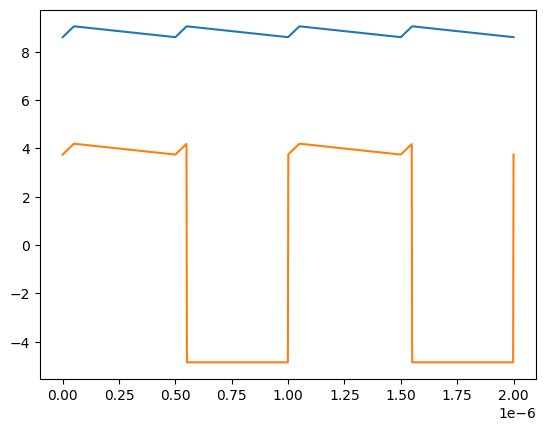

In [5]:
plt.plot(time_datapoints,I_inductor),plt.plot(time_datapoints,I_zin_ac)

In [6]:
ifft = Current_FFT(iobj)

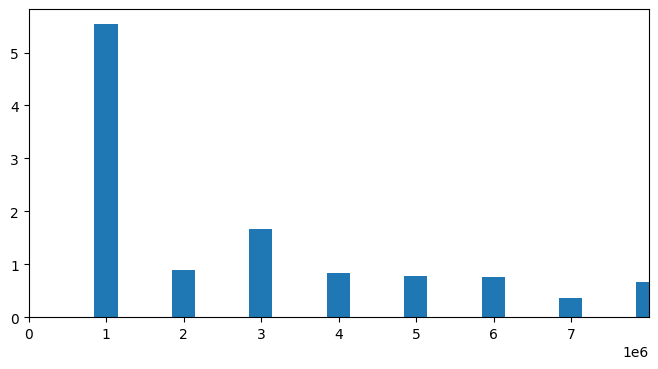

In [7]:
ifft.plot_i_zin_fft()